Parte1.1 - Onde o funil perde mais valor


In [4]:
import pandas as pd

#!! Configuração para exibir floats com 2 casas decimais por padrão
pd.options.display.float_format = '{:.2f}'.format

# 1. Lê a planilha original
df = pd.read_excel('proposta_credito.xlsx')

# 2. Tratamento: Transforma centavos em Reais criando uma coluna nova
df['valor_solicitado_reais'] = df['valor_solicitado'] / 100

# 2. Tratamento: Remove a anomalia da etapa 7 (mantém apenas as de 1 a 6)
df_limpo = df[df['etapa_max_funil'] <= 6]

# 3. Isola apenas o dinheiro perdido (descarta quem foi contratado)
propostas_perdidas = df_limpo[df_limpo['status_final'] != 'Contratada']

# 4. Agrupa pela etapa e soma o valor total solicitado em cada uma
perda_financeira = propostas_perdidas.groupby(['etapa_max_funil', 'status_final'])['valor_solicitado_reais'].sum().reset_index()

# Ordena do maior prejuízo para o menor para facilitar a leitura
perda_financeira = perda_financeira.sort_values(by='valor_solicitado_reais', ascending=False)

#!! Formatação para exibir como R$ com separadores de milhar e decimal
perda_financeira['valor_solicitado_reais'] = perda_financeira['valor_solicitado_reais'].apply(lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))

#!! Exibe o resultado na tela e tira o index do pandas
print(perda_financeira.to_string(index=False))

 etapa_max_funil          status_final valor_solicitado_reais
               4     Problema garantia      R$ 263.775.666,08
               3              Desistiu      R$ 243.107.565,29
               4           Sem retorno      R$ 233.214.084,10
               3     Reprovada crédito      R$ 231.342.027,26
               3           Sem retorno      R$ 228.596.887,55
               5 Documentação pendente      R$ 168.940.236,77
               5              Desistiu      R$ 153.852.714,60
               2              Desistiu      R$ 136.889.653,36
               2     Reprovada crédito      R$ 120.888.375,41
               2           Sem retorno      R$ 117.208.787,86
               1           Sem retorno       R$ 52.302.055,43
               1              Desistiu       R$ 52.248.439,74


Parte1.2 - Validação da Percepção da Liderança (Conversão Mensal e Canais)

--- Tendência de Conversão Mensal ---
mes_ano taxa_conversao_mensal_%
2024-01                     20%
2024-02                     20%
2024-03                     14%
2024-04                     19%
2024-05                     22%
2024-06                     14%
2024-07                     22%
2024-08                     25%
2024-09                     19%
2024-10                     23%
2024-11                     20%
2024-12                     20%
2025-01                     21%
2025-02                     17%
2025-03                     18%
2025-04                     18%
2025-05                     23%
2025-06                     21%
2025-07                     17%
2025-08                     17%
2025-09                     17%
2025-10                     15%
2025-11                     11%
2025-12                     30%


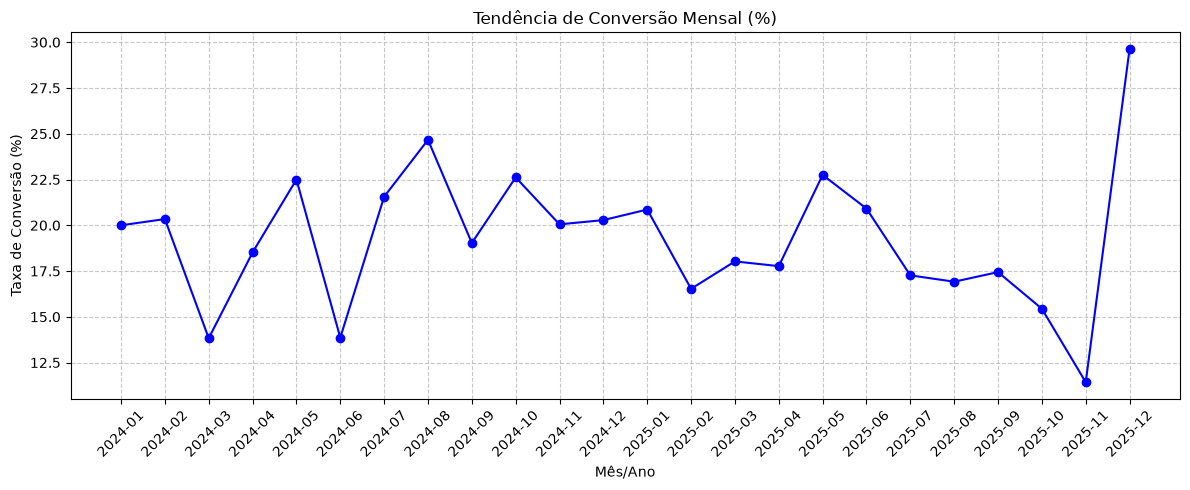


--- Performance por Canal ---
  canal_origem taxa_conversao_%  total_propostas
Correspondente              14%             1772
      Organico              21%             1411
    Mídia paga              22%             1272
     Indicação              21%              980
      Parceria              22%              965


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('proposta_credito.xlsx')
# --- TRATAMENTO EXTRA ---
#!! Padronizar o texto da coluna de canais (colocar a primeira letra em maiúsculo)
df['canal_origem'] = df['canal_origem'].str.strip().str.capitalize()

# --- AVALIAÇÃO DA CONVERSÃO AO LONGO DO TEMPO ---
# 1. Criar uma coluna agrupando a data por Mês e Ano
df['mes_ano'] = df['data_entrada'].dt.to_period('M')

# 2. Calcular a taxa de conversão mensal
conversao_mensal_df = df.groupby('mes_ano')['status_final'].apply(lambda x: (x == 'Contratada').mean() * 100).reset_index()
conversao_mensal_df.rename(columns={'status_final': 'taxa_conversao_mensal_%'}, inplace=True)

# Criamos uma cópia para o gráfico porque a formatação de string (%) impede a plotagem
conversao_mensal_plot = conversao_mensal_df.copy()
conversao_mensal_plot['mes_ano'] = conversao_mensal_plot['mes_ano'].astype(str)

#!! Formatação para exibir a taxa como porcentagem arredondada (ex: 14%) na tabela
conversao_mensal_display = conversao_mensal_df.copy()
conversao_mensal_display['taxa_conversao_mensal_%'] = conversao_mensal_display['taxa_conversao_mensal_%'].apply(lambda x: f'{int(round(x))}%')

print("--- Tendência de Conversão Mensal ---")
print(conversao_mensal_display.to_string(index=False))

# --- GRÁFICO DE TENDÊNCIA ---
plt.figure(figsize=(12, 5))
plt.plot(conversao_mensal_plot['mes_ano'], conversao_mensal_plot['taxa_conversao_mensal_%'], marker='o', linestyle='-', color='b')
plt.title('Tendência de Conversão Mensal (%)')
plt.xlabel('Mês/Ano')
plt.ylabel('Taxa de Conversão (%)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- AVALIAÇÃO DO CANAL DE CORRESPONDENTES ---
# 1. Calcular a conversão por canal
conversao_canal = df.groupby('canal_origem')['status_final'].apply(lambda x: (x == 'Contratada').mean() * 100).reset_index()

# 2. Calcular o volume total de propostas por canal (para ver se é um canal relevante)
volume_canal = df.groupby('canal_origem').size().reset_index(name='total_propostas')

# 3. Juntar as duas informações e ordenar
analise_canal = pd.merge(conversao_canal, volume_canal, on='canal_origem')
analise_canal.rename(columns={'status_final': 'taxa_conversao_%'}, inplace=True)
analise_canal = analise_canal.sort_values(by='total_propostas', ascending=False)

#!! Formatação para exibir a taxa como porcentagem arredondada (ex: 14%)
analise_canal['taxa_conversao_%'] = analise_canal['taxa_conversao_%'].apply(lambda x: f'{int(round(x))}%')

print("\n--- Performance por Canal ---")
print(analise_canal.to_string(index=False))


Parte1.3 - Características da proposta mais se associam à contratação

In [7]:
import pandas as pd

# 1. Carrega e trata a base (Valores monetários e LTV)
df = pd.read_excel('proposta_credito.xlsx')
df['valor_solicitado_reais'] = df['valor_solicitado'] / 100
df['valor_imovel_reais'] = df['valor_imovel'] / 100
df['ltv'] = df['valor_solicitado_reais'] / df['valor_imovel_reais']

# 2. Cria a coluna de sucesso (1 para Contratada, 0 para falhas)
df['sucesso'] = df['status_final'].apply(lambda x: 1 if x == 'Contratada' else 0)

# 3. TRATAMENTO DE TEXTO: Padroniza o canal para começar sempre com letra maiúscula
# Usamos str.strip() para remover espaços que podem causar duplicatas
df['canal_origem'] = df['canal_origem'].str.strip().str.capitalize()

print("--- ANÁLISE DE CATEGORIAS (Taxa de Conversão em %) ---")

# Conversão por Canal: Formatando para % e removendo duplicatas através do strip() acima
conversao_canal = df.groupby('canal_origem')['sucesso'].mean() * 100
print("\nConversão por Canal:")
# Aplicamos lambda para adicionar o símbolo % e remover a anotação de tipo do pandas
print(conversao_canal.sort_values(ascending=False).apply(lambda x: f"{x:.1f}%").to_string(name=False))

# Conversão por Tipo de Imóvel: Formatando para %
conversao_imovel = df.groupby('tipo_imovel')['sucesso'].mean() * 100
print("\nConversão por Tipo de Imóvel:")
print(conversao_imovel.sort_values(ascending=False).apply(lambda x: f"{x:.1f}%").to_string(name=False))

# Conversão por Região (UF): Formatando para %
conversao_uf = df.groupby('uf')['sucesso'].mean() * 100
print("\nConversão por Região (UF):")
print(conversao_uf.sort_values(ascending=False).apply(lambda x: f"{x:.1f}%").to_string(name=False))


print("\n\n--- ANÁLISE DE NÚMEROS (Comparação de Médias) ---")

medias_numericas = df.groupby('status_final')[['score_credito', 'valor_solicitado_reais', 'prazo_meses', 'ltv']].mean()

# 4. TRATAMENTO VISUAL: Formatando as colunas numéricas para o padrão de negócios
formatacao_negocios = {
    'score_credito': lambda x: f"{x:.0f}", # Arredonda para número inteiro
    'valor_solicitado_reais': lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."), # Padrão brasileiro de moeda
    'prazo_meses': lambda x: f"{x:.0f}", # Arredonda para meses inteiros
    'ltv': lambda x: f"{x * 100:.1f}%".replace(".", ",") # Transforma em % com 1 casa decimal
}

print(medias_numericas.to_string(formatters=formatacao_negocios))


--- ANÁLISE DE CATEGORIAS (Taxa de Conversão em %) ---

Conversão por Canal:
canal_origem
Parceria          22.3%
Mídia paga        21.5%
Indicação         21.1%
Organico          20.7%
Correspondente    14.3%

Conversão por Tipo de Imóvel:
tipo_imovel
Terreno           21.1%
Sala comercial    20.9%
Imóvel rural      20.2%
Apartamento       19.4%
Casa              18.2%

Conversão por Região (UF):
uf
GO    23.4%
DF    21.3%
MG    20.5%
SP    19.9%
BA    19.2%
PE    18.1%
RS    17.8%
SC    17.8%
PR    17.6%
RJ    17.6%


--- ANÁLISE DE NÚMEROS (Comparação de Médias) ---
                      score_credito valor_solicitado_reais prazo_meses   ltv
status_final                                                                
Contratada                      697          R$ 368.084,40         137 47,6%
Desistiu                        664          R$ 392.827,33         136 49,9%
Documentação pendente           662          R$ 383.955,08         141 48,5%
Problema garantia               660    

Parte1.4 - Recomendações Acionáveis

**1. Treinamento e Filtro Rigoroso para o Canal "Correspondentes"**

* **Contexto:** O código 1.2 mostrou que os Correspondentes trazem o maior volume (1.772 propostas), mas têm a pior taxa de conversão da empresa (apenas 14%, enquanto os outros canais operam acima de 21%).


* **Recomendação:** Implementar um "Score de Qualidade" para os correspondentes e aplicar treinamentos de reciclagem na política de crédito do Bari. Paralelamente, criar uma trava no sistema que os impeça de inserir propostas fora da esteira (ex: clientes com LTV muito alto).
* **Prioridade:** **Alta.** É o gargalo mais evidente de conversão e afeta o canal de maior volume.


* **Impacto Estimado:** Se o canal de Correspondentes for otimizado para atingir a conversão média dos outros canais (21%), teremos cerca de 118 novos contratos gerados. Com o ticket médio de R$ 368 mil, isso injetaria aproximadamente **R$ 43,7 Milhões** em novos contratos na carteira.


* **Premissas Assumidas:** Assumo que a baixa conversão se deve à má qualificação prévia feita pelo correspondente (trazendo leads que não se encaixam no perfil) e que uma reciclagem conseguiria elevar a qualidade dos leads ao padrão orgânico.

**2. Implementar "Hard Stop" (Filtro Automático) na Etapa 1**

* **Contexto:** A política interna determina limite de 60% de LTV. Além disso, encontramos na base propostas cuja parcela seria maior que 100% da renda do cliente. Apesar de ferirem as regras, muitas avançam no funil. E na análise financeira (1.1), o maior volume de dinheiro perdido (R$ 263 Milhões) acontece na Etapa 4 por "Problema de garantia".


* **Recomendação:** Criar um bloqueio de sistema automático (hard stop) na Etapa 1. Propostas com LTV > 60% ou comprometimento de renda absurdo não devem poder passar para as etapas de análise humana sem aprovação de alçada excepcional.
* **Prioridade:** **Alta.** Trata-se de redução de custo operacional imediato.
* **Impacto Estimado:** Na base atual, cerca de 1.745 propostas fora da política (LTV alto ou renda insuficiente) avançaram até a Etapa 3 ou superior. Cortar isso na raiz economizaria **58.333 dias somados de tempo de análise**, liberando a equipe para focar nas propostas com chances reais de sucesso (score médio de 697 e LTV < 48%).


* **Premissas Assumidas:** O custo de análise é proporcional aos dias trabalhados. Assumo que "Problemas de garantia" tardios muitas vezes estão ligados ao imóvel não cobrir o alto LTV solicitado.

**3. Automação de Follow-up (Retorno) nas Etapas 3 e 4**

* **Contexto:** A Parte 1.1 revelou que as Etapas 3 e 4 perdem muito dinheiro por motivos que indicam falta de engajamento: R$ 243 Milhões em "Desistiu" (Etapa 3) e R$ 233 Milhões em "Sem retorno" (Etapa 4).


* **Recomendação:** Implementar alertas de SLA (tempo de resposta) para os consultores quando uma proposta ficar estagnada nessas etapas, e disparar comunicações automáticas (WhatsApp/Email) para clientes que estão com pendências na Etapa 4 para evitar que fiquem "Sem Retorno".
* **Prioridade:** **Média.** Depende de ferramentas de CRM, mas tem alto valor de recuperação.
* **Impacto Estimado:** Juntas, as perdas por "Sem Retorno" e "Desistência" no meio do funil somam R$ 476 Milhões. Se essa automação conseguir recuperar e converter apenas **5%** dessas propostas, são **R$ 23,8 Milhões** resgatados do lixo.


* **Premissas Assumidas:** Assumo que grande parte das desistências e faltas de retorno nesse estágio avançado ocorrem por lentidão na resposta do Bari ou esquecimento/burocracia por parte do cliente, o que pode ser mitigado por automação de avisos.